In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    ModelType,
    FittingStage,
    InitStrategy,
    TPGMMConfig,
    AutoTPGMMConfig,
    AutoTPGMM,
    FrameSelectionConfig,
    DemoSegmentationConfig,
    CascadeConfig,
)

from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-06-14 17:10:35.518 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from pathlib import Path

import h5py
from heca.environment.scenes.scene import Scene
from heca.environment.scenes.ogbench.temp import TempScene

from heca.agents.experts.expert import ExpertAgent
from heca.agents.experts.tapas import TapasAgent

scene_cfg = TempScene.Config()  # OGBenchScene.Config()
agent_cfg = TapasAgent.Config(
    folder="open_window",
    scene=scene_cfg,
    use_gt=True,
)
scene = Scene.get(scene_cfg, load=False)
agent_dir = ExpertAgent.resolve(agent_cfg)
model_file_name = "policy_gt.pt" if agent_cfg.use_gt else "policy_img.pt"
file_path = Path.cwd().parent.parent.parent / agent_dir / "demos.h5"
save_path = Path.cwd().parent.parent.parent / agent_dir / model_file_name
print(agent_dir)
print(file_path)
print(save_path)

2026-06-14 17:10:36.596 | INFO     | heca.misc.logger:info:30 - Running on cpu


I0000 00:00:1781449838.059179 2616389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781449838.091010 2616389 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781449838.849592 2616389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


data/experts/tapas/open_window
/home/jangruhnert/Documents/GitHub/master-project/data/experts/tapas/open_window/demos.h5
/home/jangruhnert/Documents/GitHub/master-project/data/experts/tapas/open_window/policy_gt.pt


In [3]:
from tensordict import TensorDict
import torch
from tapas_gmm_modified.utils.observation import (
    SceneObservation,
    dict_to_tensordict,
)
from heca.entities.entity import Mobility
from heca.misc.td import TDScene, empty_bs

def tapas_td(td_obs: TDScene, td_goal: TDScene, scene: Scene) -> TensorDict:
    action = td_obs.extras["action"]
    reward = td_obs.extras["reward"]
    joint_pos = td_obs.extras["joint_pos"]
    joint_vel = td_obs.extras["joint_vel"]
    cursor = td_obs["cursor"]
    cursor_pos = cursor.position
    cursor_rot = cursor.rotation
    cursor_state = cursor.state
    ee_pose = torch.cat((cursor_pos, cursor_rot), dim=-1)
    ee_state = cursor_state

    # camera_obs = self.image_tensors(obs)

    # multicam_obs = dict_to_tensordict(
    #    {"_order": CameraOrder._create(obs.camera_names)} | camera_obs  # type: ignore
    # )
    poses = {
            entity.cfg.label: torch.cat(
                [
                    td_obs[entity.cfg.label].position,
                    td_obs[entity.cfg.label].rotation,
                ],
                dim=-1,
            )
            for entity in scene.entities
        }

    states = {
        entity.cfg.label: td_obs[entity.cfg.label].state
        for entity in scene.entities
    }

    for entity in scene.entities:
        # This adds target frames for mobile entities.
        # Later can be used to set target for the tapas model
        if entity.cfg.mobility == Mobility.FREE:
            pos = td_goal[entity.cfg.label].position
            rot = td_goal[entity.cfg.label].rotation
            state = td_goal[entity.cfg.label].state
            pose = torch.cat((pos, rot), dim=-1)
            poses[f"{entity.cfg.label}_target"] = pose
            states[f"{entity.cfg.label}_target"] = state

    gcursor = td_goal["cursor"]
    gcursor_pos = gcursor.position
    gcursor_rot = gcursor.rotation
    gcursor_state = gcursor.state
    gee_pose = torch.cat((gcursor_pos, gcursor_rot), dim=-1)
    gee_state = gcursor_state
    poses[f"ee_target"] = gee_pose
    states[f"ee_target"] = gee_state
   
    object_poses = dict_to_tensordict(poses)
    object_states = dict_to_tensordict(states)

    return SceneObservation(
            feedback=reward,
            action=action,
            cameras=None,  # multicam_obs,
            ee_pose=ee_pose,
            gripper_state=ee_state,
            object_poses=object_poses,
            object_states=object_states,
            joint_pos=joint_pos,
            joint_vel=joint_vel,
            batch_size=empty_bs,
        )

In [4]:
demos_file = h5py.File(file_path, "r")
# load observations here
print(demos_file.keys())
observations: list[SceneObservation] = []  # type: ignore

demos_scenes, demos_images = scene.load_dataset(demos_file) 
for i, (demo_scenes, demo_images) in enumerate(zip(demos_scenes, demos_images)):
    if not agent_cfg.use_gt:
        raise NotImplementedError("TODO: implement tapas_td and convert demos to tapas format")
        # TODO:
    else:
        obss: list[TensorDict] = []
        for td_scene in demo_scenes:
            td_obs = td_scene
            td_goal = demo_scenes[-1]
            obs = tapas_td(td_obs, td_goal, scene)
            obss.append(obs)
        stacked_obs = TensorDict.stack(obss, dim=0)
        observations.append(stacked_obs)

<KeysViewHDF5 ['actions', 'button_states', 'control', 'demo', 'depth', 'extrinsics', 'intrinsics', 'mask', 'prev_button_states', 'prev_qpos', 'prev_qvel', 'privileged_block_0_pos', 'privileged_block_0_quat', 'privileged_block_0_state', 'privileged_block_0_yaw', 'privileged_button_0_pos', 'privileged_button_0_quat', 'privileged_button_0_state', 'privileged_button_0_vel', 'privileged_button_1_pos', 'privileged_button_1_quat', 'privileged_button_1_state', 'privileged_button_1_vel', 'privileged_drawer_handle_pos', 'privileged_drawer_handle_quat', 'privileged_drawer_handle_state', 'privileged_drawer_handle_yaw', 'privileged_drawer_pos', 'privileged_drawer_vel', 'privileged_target_block', 'privileged_target_block_pos', 'privileged_target_block_quat', 'privileged_target_block_yaw', 'privileged_target_button', 'privileged_target_button_quat', 'privileged_target_button_state', 'privileged_target_button_top_pos', 'privileged_target_drawer_handle_pos', 'privileged_target_drawer_pos', 'privileged_

In [5]:
data_kwargs = dict(
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)

demos = Demos(observations, **data_kwargs) #type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names

2026-06-14 17:10:41.890 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:649 - Subsampling to length 34 using strategy mean-length.
n_trajs 10
n_frames 8


('ee_init',
 'drawer_handle',
 'window_handle',
 'button_0',
 'button_1',
 'block_0',
 'block_0_target',
 'ee_target')

In [6]:
frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    use_bic=False,
    drop_redundant_frames=False,
    rel_score_threshold=0.0,
    gt_frames=[[0, 2, 4], [2, 4], [4, 7]],  # Frames per segment
)


tpgmm_config = TPGMMConfig(
    n_components=20,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=True,
    add_gripper_action=True,
    reg_shrink=1e-2,
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,
    trans_cov_mask_t_pos_corr=False,
    em_steps=50,
    fix_first_component=False, # True maybe
    fix_last_component=False, #True maybe
    reg_init_diag=5e-4,  # 5
    heal_time_variance=False,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    use_bic=False,
    drop_redundant_frames=False,
    rel_score_threshold=0.0,
    gt_frames= [[0,3], [3,7]] #Frames per segment
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    repeat_final_step=0, #1
    repeat_first_step=0,
    components_prop_to_len=True,
    velocity_threshold=0.3,
)

cascade_config = CascadeConfig(
    kl_keep_time_dim=True,
    kl_keep_rotation_dim=False,
)

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [7]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2026-06-14 17:10:41.928 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-06-14 17:10:41.928 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-14 17:10:41.928 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


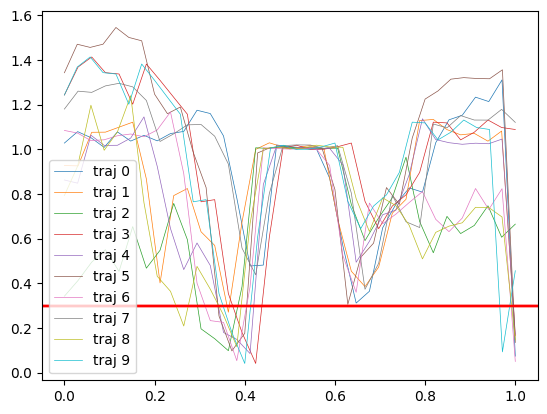

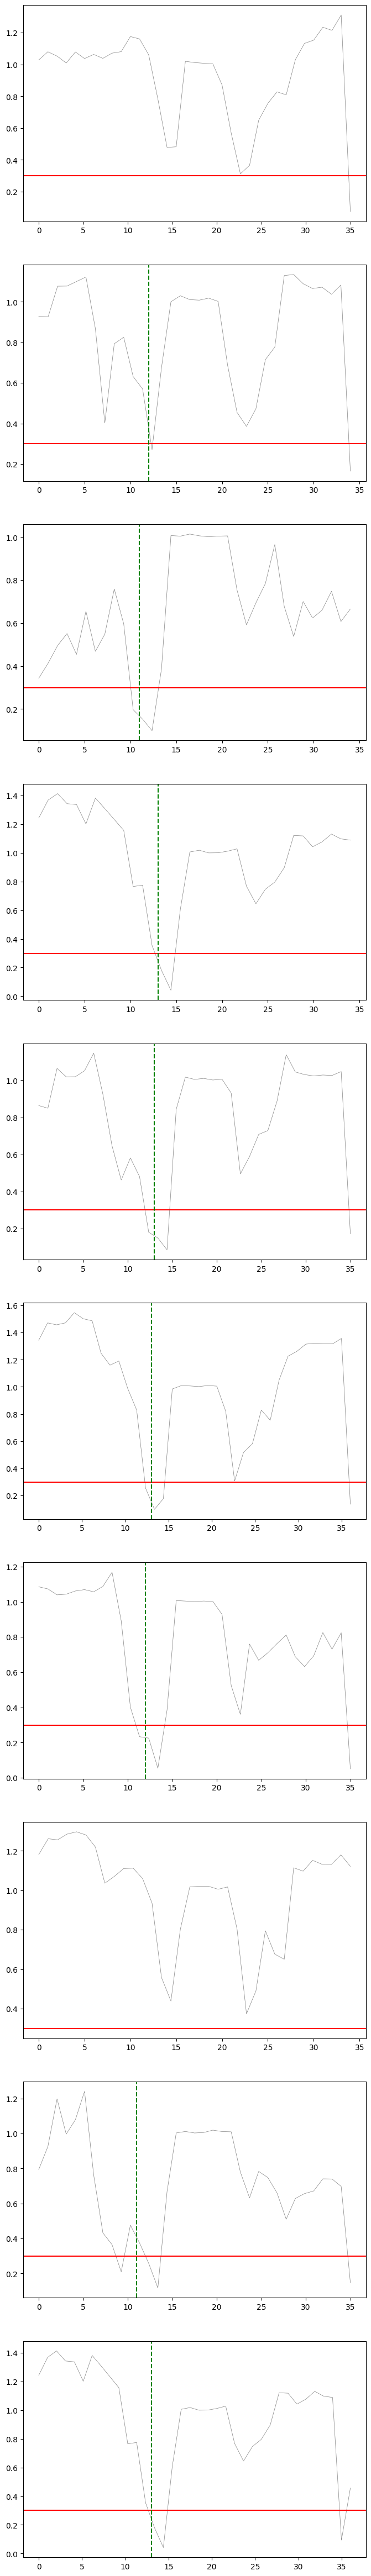

2026-06-14 17:10:42.720 | WARNING  | tapas_gmm_modified.dataset.demos:_get_segmentation_indeces_velocity_based:2184 - Got different number of segmentation points for different trajectories.
Assuming it's because of settlement time.
Popping (tensor(12, dtype=torch.int32),) from traj 1 of len 34
2026-06-14 17:10:42.721 | WARNING  | tapas_gmm_modified.dataset.demos:_get_segmentation_indeces_velocity_based:2184 - Got different number of segmentation points for different trajectories.
Assuming it's because of settlement time.
Popping (tensor(11, dtype=torch.int32),) from traj 2 of len 34
2026-06-14 17:10:42.721 | WARNING  | tapas_gmm_modified.dataset.demos:_get_segmentation_indeces_velocity_based:2184 - Got different number of segmentation points for different trajectories.
Assuming it's because of settlement time.
Popping (tensor(13, dtype=torch.int32),) from traj 3 of len 34
2026-06-14 17:10:42.721 | WARNING  | tapas_gmm_modified.dataset.demos:_get_segmentation_indeces_velocity_based:2184

Time-based init:   0%|          | 0/20 [00:00<?, ?it/s]

2026-06-14 17:10:42.734 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-06-14 17:10:42.734 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2503 - Creating partial frame view of demos.
2026-06-14 17:10:42.734 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:649 - Subsampling to length 34 using strategy mean-length.
2026-06-14 17:10:42.736 | WARNING  | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:706 - Riemannian GMMs only make sense for rotations.
2026-06-14 17:10:42.736 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x R1
2026-06-14 17:10:42.736 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:42.736 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-14 17:10:42.736 | INFO     | tapas_gmm_modified.policy.models

Time-based init:   0%|          | 0/20 [00:00<?, ?it/s]

2026-06-14 17:10:42.747 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-06-14 17:10:42.747 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2503 - Creating partial frame view of demos.
2026-06-14 17:10:42.747 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:649 - Subsampling to length 34 using strategy mean-length.
2026-06-14 17:10:42.749 | WARNING  | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:706 - Riemannian GMMs only make sense for rotations.
2026-06-14 17:10:42.749 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x R1
2026-06-14 17:10:42.749 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:42.749 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-14 17:10:42.749 | INFO     | tapas_gmm_modified.policy.models

...

2026-06-14 17:10:42.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - ee_init    score (rel):     -1 (1.000)
2026-06-14 17:10:42.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - drawer_handle score (rel):     -0 (0.367)
2026-06-14 17:10:42.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - window_handle score (rel):     -0 (0.413)
2026-06-14 17:10:42.842 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - button_0   score (rel):     -0 (0.368)
2026-06-14 17:10:42.842 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - button_1   score (rel):     -0 (0.368)
2026-06-14 17:10:42.842 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - block_0    score (rel):     -0 (0.001)
2026-06-14 17:10:42.842 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - block_0_target score (rel):     -0 (0.001)
2026-06-14 17:10:42.842 | INFO 

Fitting segments:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-14 17:10:42.861 | WARNING  | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:706 - Riemannian GMMs only make sense for rotations.
2026-06-14 17:10:42.861 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x R3 x R1
2026-06-14 17:10:42.861 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:42.861 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-14 17:10:42.861 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/20 [00:00<?, ?it/s]

((array([[7.40e+005, 5.46e+005, 2.94e+004, ..., 5.21e-296, 3.77e-314,
          0.00e+000],
         [8.33e+002, 5.02e+004, 2.71e+005, ..., 2.65e-275, 1.49e-292,
          5.37e-311],
         [1.02e-004, 3.37e-001, 1.77e+002, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         ...,
         [0.00e+000, 0.00e+000, 6.12e-311, ..., 2.00e+001, 2.31e-002,
          7.98e-004],
         [3.08e-285, 1.40e-264, 1.58e-244, ..., 5.54e+004, 1.03e+004,
          1.65e+003],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 7.07e+004, 3.07e+005,
          1.55e+004]]),),
 (-11.863763043373654,))

In [8]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,)) # FittingStage.EM_HMM))


2026-06-14 17:10:42.960 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.


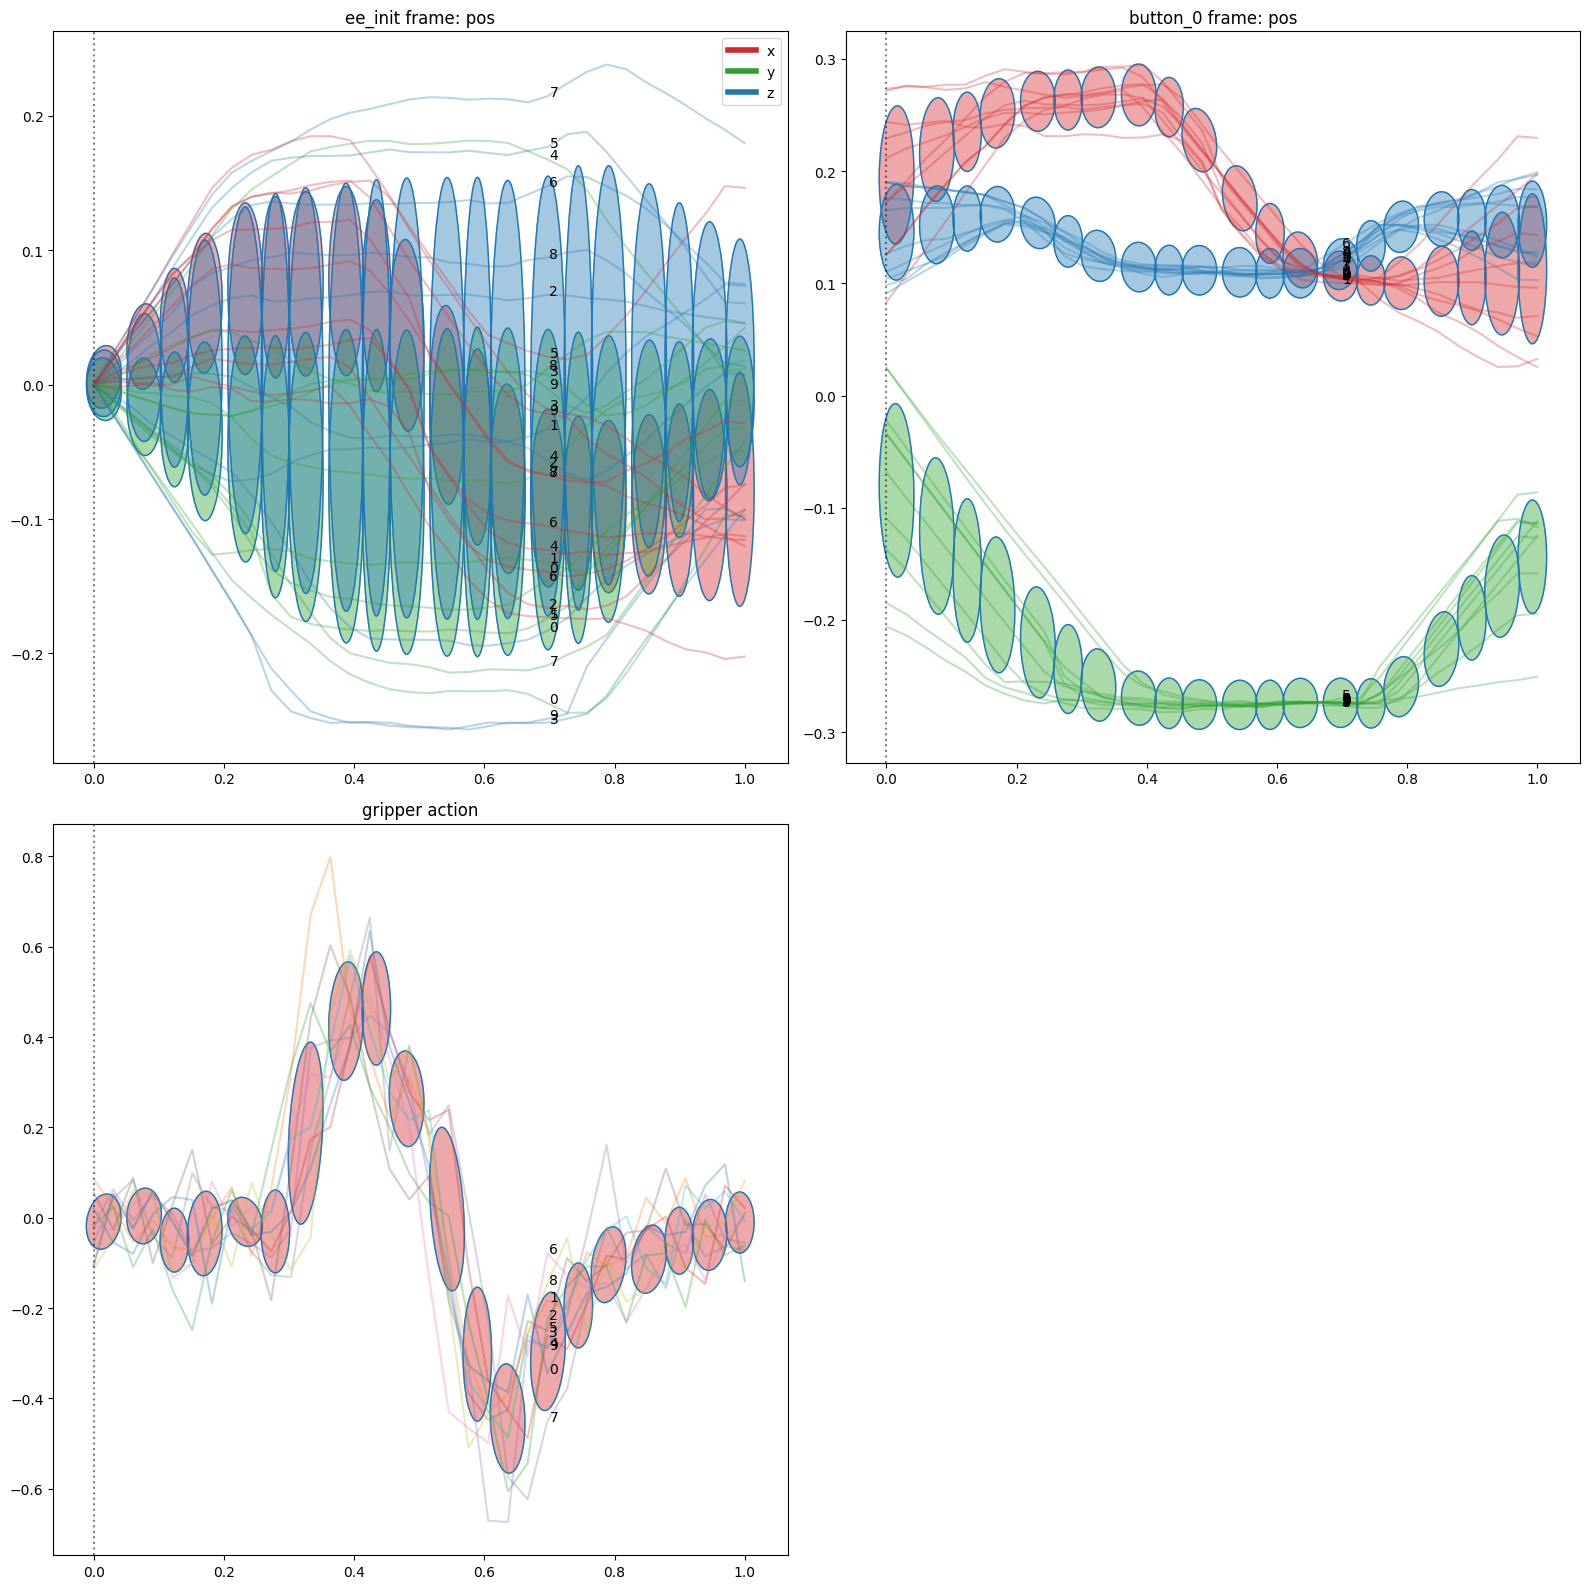

In [9]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [10]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2026-06-14 17:10:43.728 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-06-14 17:10:43.728 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-14 17:10:43.731 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-06-14 17:10:43.731 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-06-14 17:10:43.733 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-06-14 17:10:43.740 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-06-14 17:10:45.946 | WARNING  | riepybdlib.statistics:em:2262 - HMM EM did not converge


((array([[1.00e+000, 9.15e-001, 2.69e-003, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.87e-203, 8.51e-002, 9.95e-001, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 3.71e-208, 1.91e-003, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         ...,
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 3.33e-009, 3.42e-018,
          1.80e-026],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 7.61e-002, 2.80e-004,
          1.66e-007],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 9.24e-001, 1.00e+000,
          1.00e+000]]),),
 (506.41837968484253,))

2026-06-14 17:10:45.982 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.


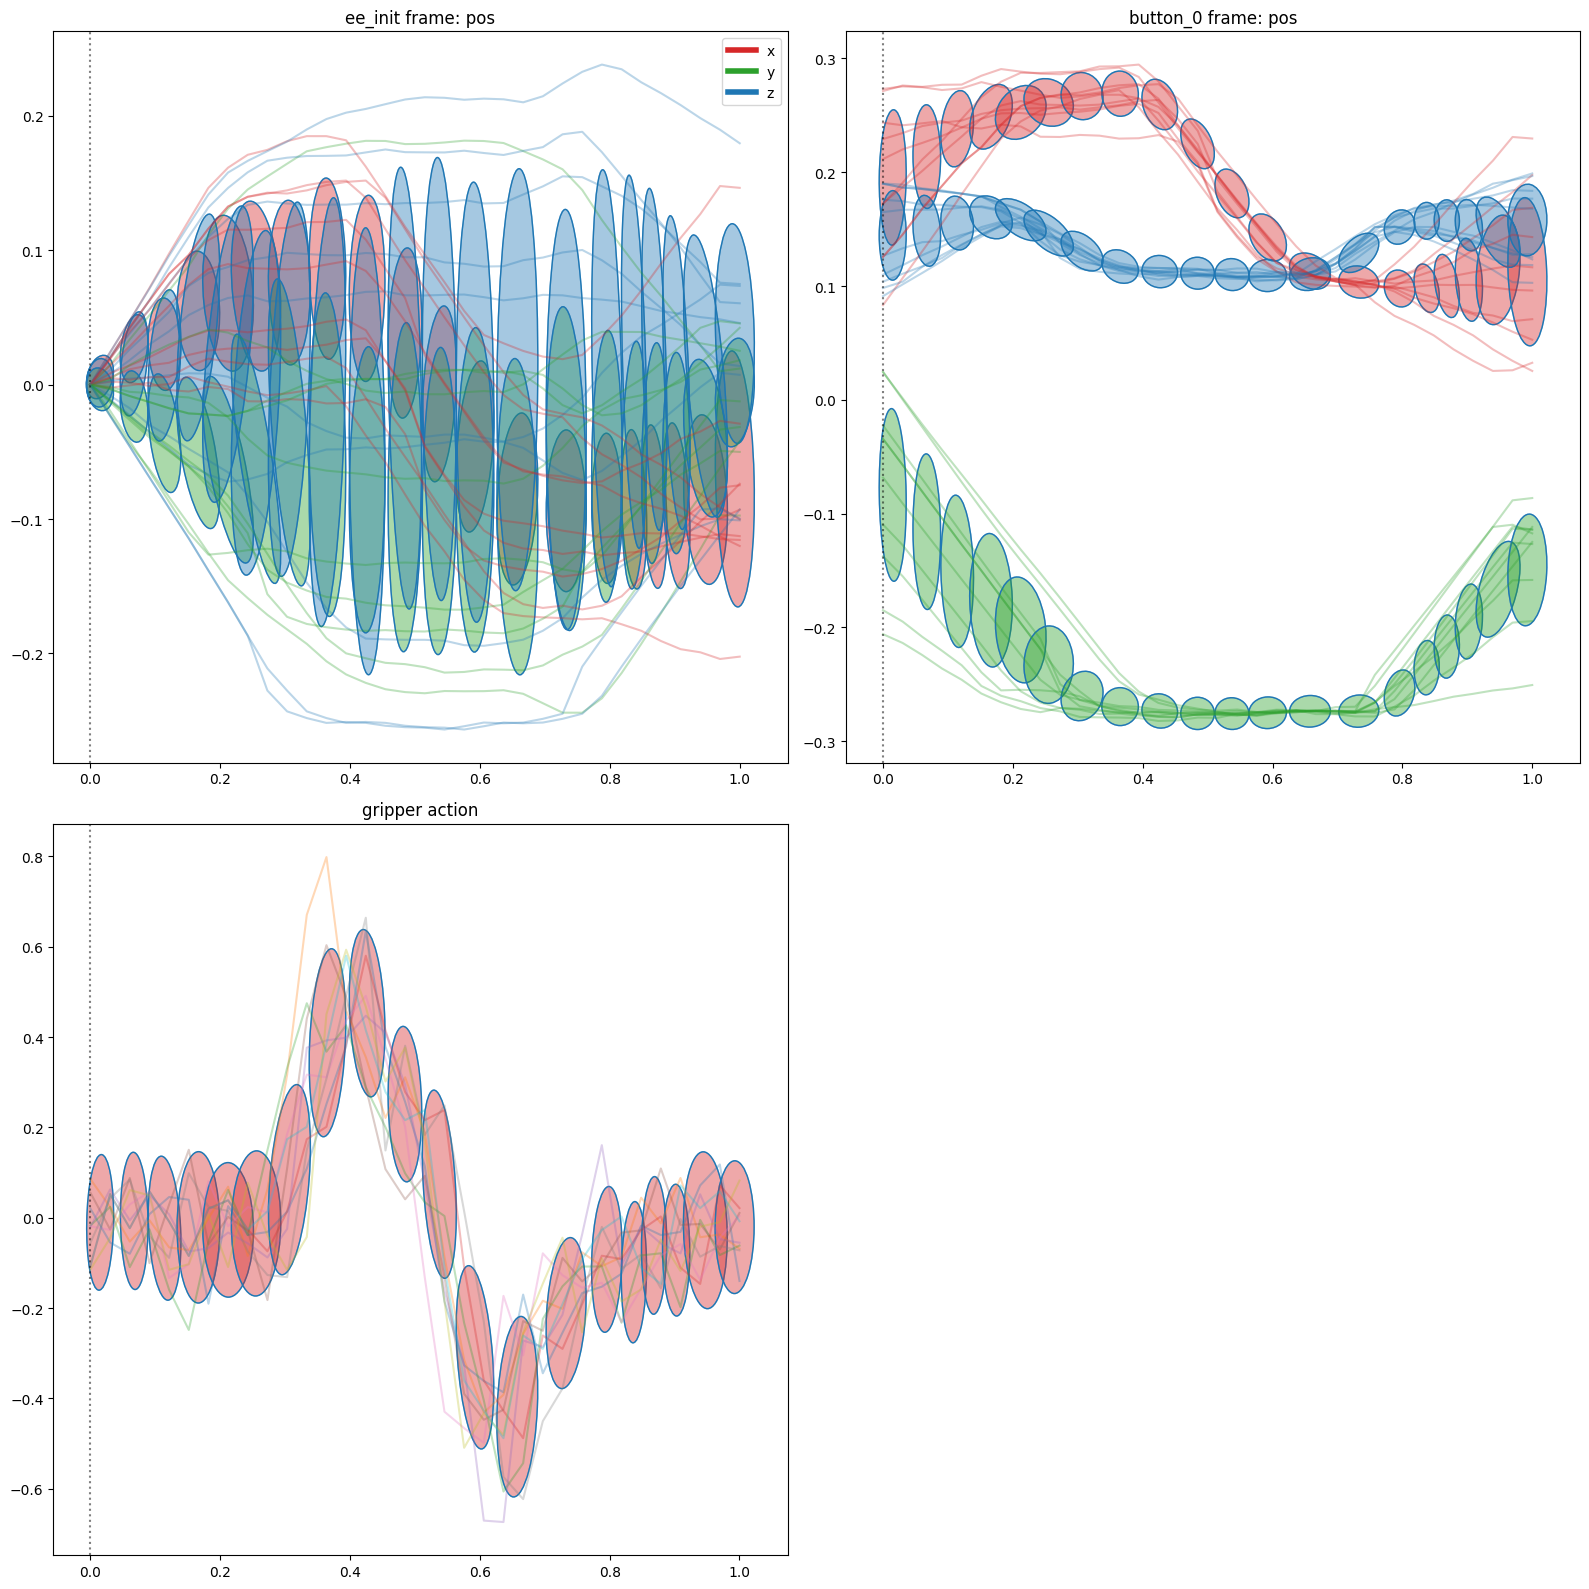

In [11]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

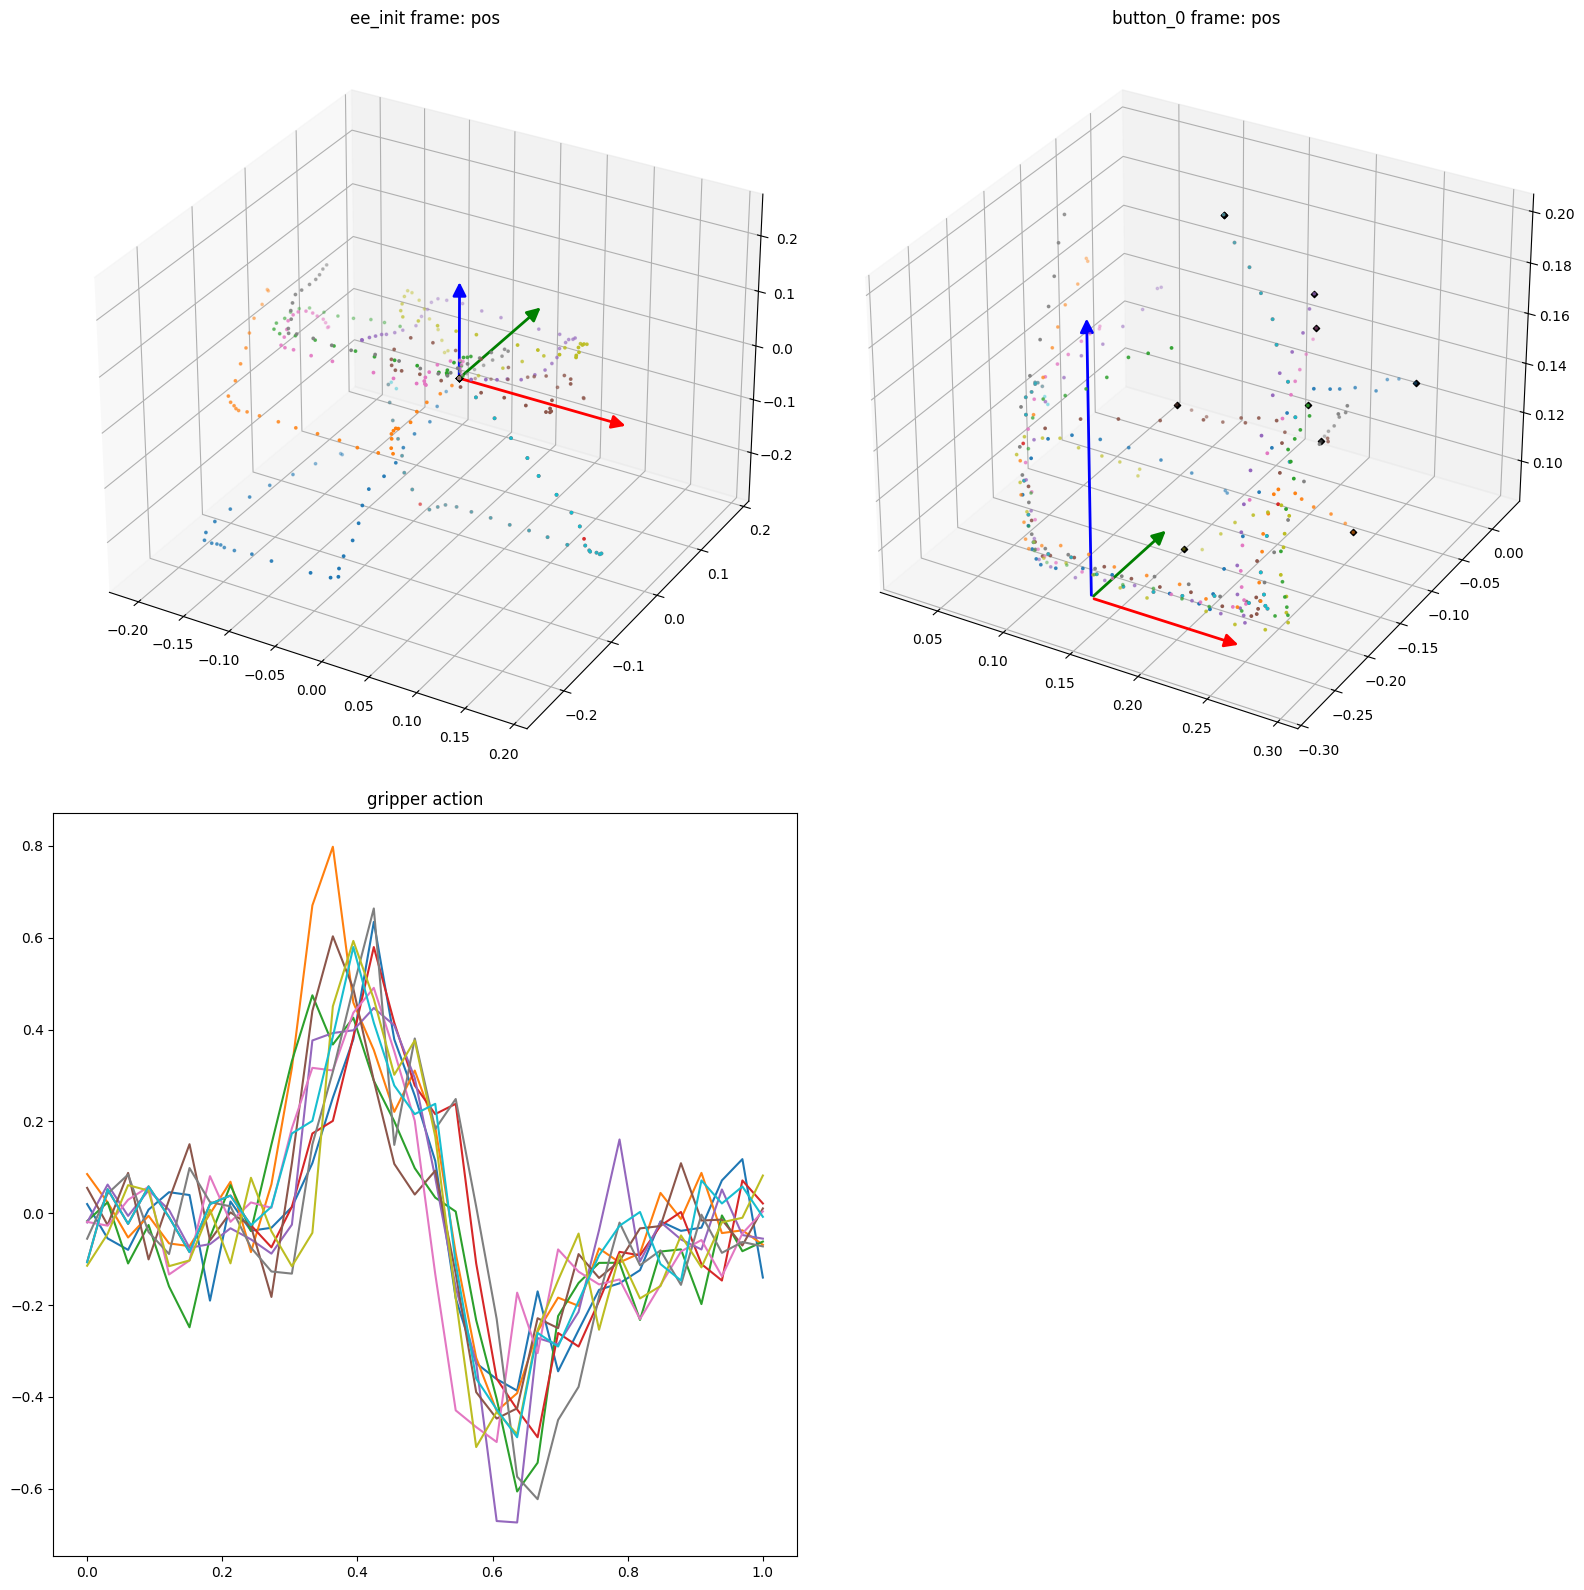

In [12]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=False,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False, time_based=False)

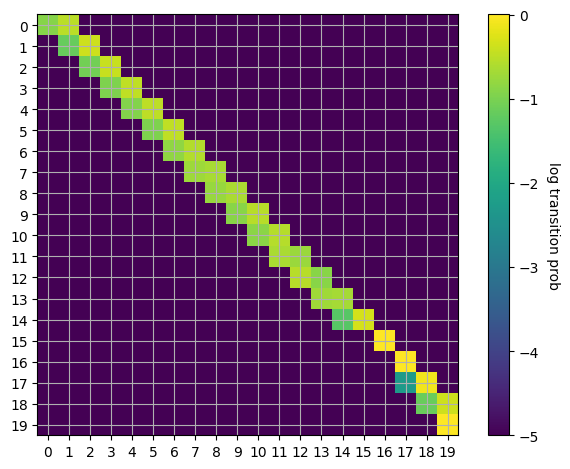

In [13]:
atpgmm.plot_hmm_transition_matrix()

In [14]:
atpgmm.to_disk(save_path) # type: ignore

2026-06-14 17:10:47.224 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [15]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


2026-06-14 17:10:47.260 | INFO     | tapas_gmm_modified.policy.models.tpgmm:reconstruct:3239 - Time-based reconstruction not specified. Auto selected True.
2026-06-14 17:10:47.262 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:840 - Assuming zero frame velocity. Should be fixed.
2026-06-14 17:10:47.262 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.263 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20


Transforming marginals:   0%|          | 0/10 [00:00<?, ?it/s]

2026-06-14 17:10:47.266 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.268 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.269 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.270 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.271 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.271 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.272 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.273 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.273 | INFO     | riepybdlib.statisti

Joining marginals:   0%|          | 0/10 [00:00<?, ?it/s]

2026-06-14 17:10:47.285 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.289 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.293 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.297 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.301 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.305 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.309 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.311 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.314 | INFO     | riepybdlib.statisti

GMR:   0%|          | 0/10 [00:00<?, ?it/s]

2026-06-14 17:10:47.322 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.369 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.410 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.451 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.493 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.535 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.579 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.621 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 20
2026-06-14 17:10:47.662 | INFO     | riepybdlib.statisti

ValueError: not enough values to unpack (expected 6, got 4)

In [ ]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

In [ ]:

atpgmm.plot_reconstructions(
    seg_trans_marg_container, cascaded_hmms, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=True, equal_aspect=False, per_segment=False)


In [ ]:
atpgmm.plot_reconstructions(
    seg_trans_marginals, seg_joint_models, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=False, equal_aspect=True, per_segment=False)
